In [2]:
#Importing python Libraries required for data analysis and visualization

import pandas as pd   #(Pandas for handling data)
import numpy as np    #(Numpy for numerical operations)
import matplotlib.pyplot as plt   #(Matplotlib for visulization)



In [3]:
# Loading the dataset into dataframe for analysis

df = pd.read_csv("cookie_cats.csv")    #(Imported csv file)


In [4]:
#taking a quick look at our dataset

df.head()    #(Displays the first five rows of dataset)

#displays the types of values
#We can see column names

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
#Checking the structure of dataset

df.info()    #(I used this to check wether dataset is clean and have no missing values)

#shows numbers of rows and columns
#data types of each column



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [6]:
#This will display statistical summary of the dataset(numerical columns)

df.describe()    #(helps to understand the data distribution)

#With help of this we have MEAN , Maximum & Minimum values , Standard deviation

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [7]:
#Checking the distribution users in groups

df["version"].value_counts()    #(To check wether both groups are balanced)

#This will show number of users in gate_30
#This will show number of users in gate_40 (Test group)

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [8]:
#I am calculating the average retention rate of each group

df.groupby("version")["retention_1"].mean()       #(Comparing A/B test results)

#This will tell which group has higher retention


version
gate_30    0.448188
gate_40    0.442283
Name: retention_1, dtype: float64

NEXT STEP : Hypothesis Testing(A/B)

- Objective of this is to determine whether changing the game level gate from 30 to 40 has a statistical impact on players retention. -

- Starting with setting up our hypotheses:

> NUll Hypothesis: There is no difference in retention between two groups.

> Alternative hypothesis : The New version(gate_40) is better.


In [9]:
#Preparing Data

#Group data
group_A = df[df["version"] == "gate_30"]["retention_1"]
group_B = df[df["version"] == "gate_40"]["retention_1"]

In [ ]:
#Applying Z_Test 

#We use Z-Test When the data is binary and sample size is large 

from statsmodels.stats.proportion import proportions_ztest

# Success count
success = [group_A.sum(), group_B.sum()]

# Total observations
nobs = [len(group_A), len(group_B)]

# Z-test
z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)


Z-statistic: 1.7840862247974725
P-value: 0.07440965529691913


In [13]:
#This shows which version Performs better 

retention_A = group_A.mean()
retention_B = group_B.mean()

print("Retention (gate_30):", retention_A)
print("Retention (gate_40):", retention_B)
print("Difference:", retention_B - retention_A)

Retention (gate_30): 0.4481879194630872
Retention (gate_40): 0.44228274967574577
Difference: -0.005905169787341458


After performing the two-proportion Z-test, the p-value obtained is 0.0744, which is greater than the significance level of 0.05.

This means that we fail to reject the null hypothesis. In simple terms, although there is a slight difference observed in retention between the two versions (gate_30 and gate_40), this difference is not statistically significant.

Therefore, we cannot confidently conclude that changing the game level gate from 30 to 40 has a real impact on player retention. The observed difference may simply be due to random variation rather than an actual improvement.

--> Final Insight:
While the new version (gate_40) may appear to perform slightly better, the statistical evidence is not strong enough to support a meaningful improvement in retention.

## Next Step : Confidence Interval

In [14]:
import numpy as np

# Conversion rates
p1 = group_A.mean()
p2 = group_B.mean()

# Sample sizes
n1 = len(group_A)
n2 = len(group_B)

# Difference
diff = p2 - p1

# Standard error
se = np.sqrt((p1*(1-p1)/n1) + (p2*(1-p2)/n2))

# Confidence Interval (95%)
lower = diff - 1.96 * se
upper = diff + 1.96 * se

print("Confidence Interval:")
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Confidence Interval:
Lower Bound: -0.012392558656738065
Upper Bound: 0.0005822190820551484


## Confidence Interval Analysis

The calculated 95% confidence interval for the difference in retention between the two groups is:

Lower Bound: -0.0124
Upper Bound: 0.0006
🧠 Interpretation

The confidence interval includes the value 0, which indicates that the true difference in retention between the two groups could be zero.

This means that there is no statistically significant difference between the control group (gate_30) and the test group (gate_40).

In other words, although there is a slight observed difference in retention, it is not strong enough to conclude that the change in game design had a real impact.

## Next Step : Visulization

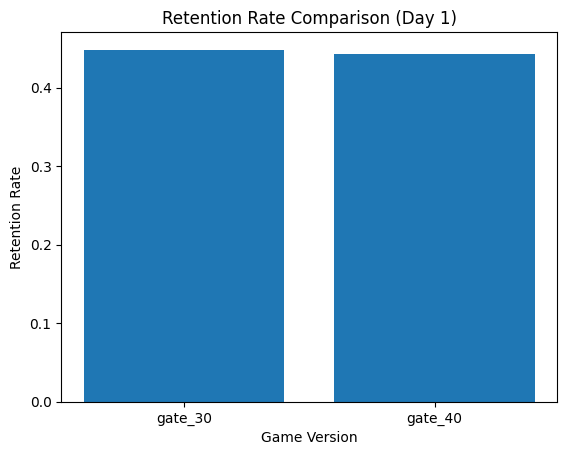

In [15]:
#1. Retention Rate Comparison

labels = ['gate_30', 'gate_40']
values = [p1, p2]

plt.figure()
plt.bar(labels, values)
plt.title("Retention Rate Comparison (Day 1)")
plt.xlabel("Game Version")
plt.ylabel("Retention Rate")
plt.show()

-->The bar chart shows a slight difference in retention rates between the two groups. However, the difference is minimal and not visually significant.

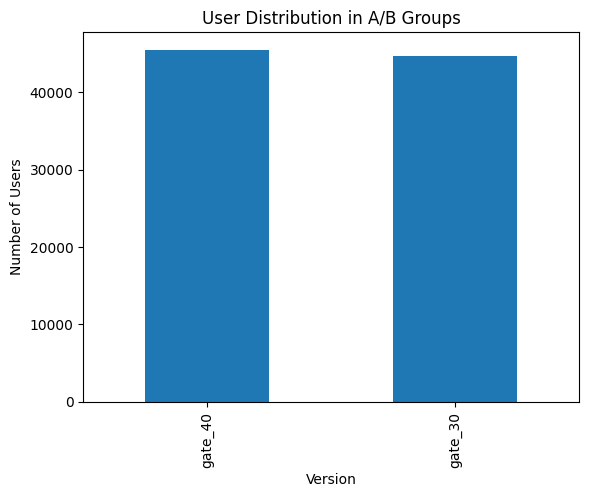

In [16]:
#2. User Distribution

df["version"].value_counts().plot(kind='bar')

plt.title("User Distribution in A/B Groups")
plt.xlabel("Version")
plt.ylabel("Number of Users")
plt.show()


-->The number of users in both groups is nearly balanced, ensuring a fair comparison for A/B testing

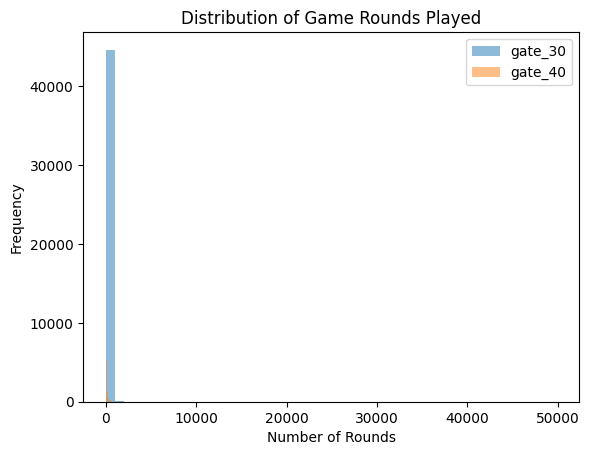

In [18]:
#3. Distribution of Game Rounds

plt.figure()

plt.hist(df[df["version"] == "gate_30"]["sum_gamerounds"], bins=50, alpha=0.5, label='gate_30')
plt.hist(df[df["version"] == "gate_40"]["sum_gamerounds"], bins=50, alpha=0.5, label='gate_40')

plt.title("Distribution of Game Rounds Played")
plt.xlabel("Number of Rounds")
plt.ylabel("Frequency")
plt.legend()
plt.show()

-->The distribution shows that most users play a small number of rounds, while a few users play significantly more, indicating the presence of outliers.

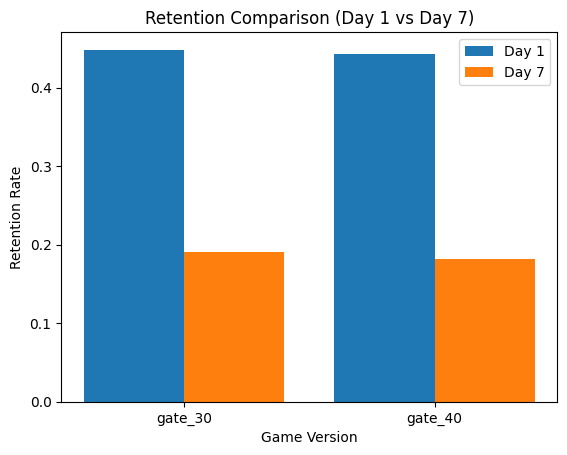

In [19]:
#4. Retention Comparison

retention_1 = df.groupby("version")["retention_1"].mean()
retention_7 = df.groupby("version")["retention_7"].mean()

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, retention_1, width=0.4, label='Day 1')
plt.bar(x + 0.2, retention_7, width=0.4, label='Day 7')

plt.xticks(x, labels)
plt.title("Retention Comparison (Day 1 vs Day 7)")
plt.xlabel("Game Version")
plt.ylabel("Retention Rate")
plt.legend()
plt.show()


-->Retention drops significantly from Day 1 to Day 7, which is expected behavior in most mobile games